# Lane Detection Test Notebook

This notebook runs quick sanity checks for the lane detection/demo code in this repository. It demonstrates classic OpenCV lane detection and an optional YOLOv8 + BEV pathway.

In [ ]:
# Import project modules and helper functions
import sys

sys.path.append("../src")  # add repo src to path

from ui import road_lanes
import os

import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Loaded modules: road_lanes and lane_demo helpers")

Loaded modules: road_lanes and lane_demo helpers


(np.float64(-0.5), np.float64(1279.5), np.float64(719.5), np.float64(-0.5))

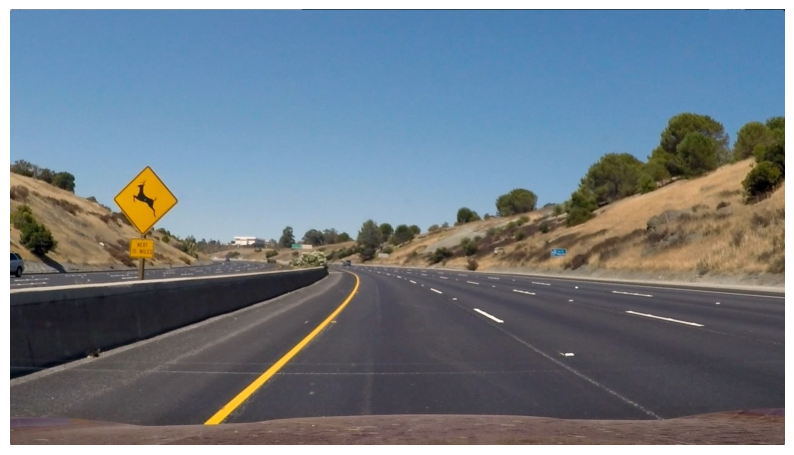

In [5]:
# Load a single frame and display
# Use the existing plt import (do not re-import). Iterate over filenames in sample_images,
# and skip files that cannot be read.
frame = cv2.imread(os.path.join("../assets/lane", "test2.jpg"))

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.axis("off")

(np.float64(-0.5), np.float64(1279.5), np.float64(719.5), np.float64(-0.5))

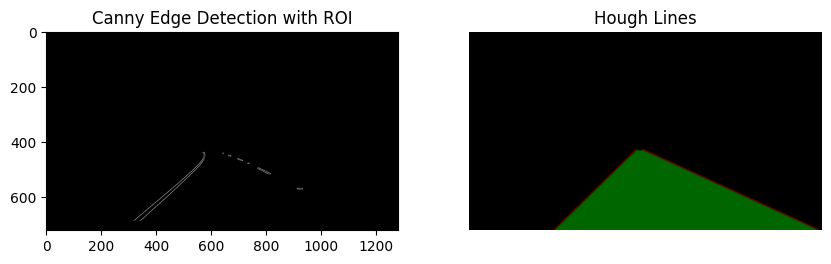

In [ ]:
from ui.road_lanes import (
    grayscale,
    gaussian_blur,
    canny,
    region_of_interest,
    get_vertices,
    hough_lines,
)

image = frame.copy()
# Grayscale
gray_img = grayscale(image)

# Gaussian Smoothing
smoothed_img = gaussian_blur(img=gray_img, kernel_size=5)
# Canny Edge Detection
canny_img = canny(img=smoothed_img, low_threshold=180, high_threshold=240)
masked_img = region_of_interest(img=canny_img, vertices=get_vertices(image))
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.imshow(masked_img, cmap="gray")
plt.title("Canny Edge Detection with ROI")
plt.subplot(1, 2, 2)
houghed_lines = hough_lines(
    img=masked_img,
    rho=1,
    theta=np.pi / 180,
    threshold=20,
    min_line_len=20,
    max_line_gap=180,
)
plt.imshow(houghed_lines, cmap="gray")
plt.title("Hough Lines")

plt.axis("off")

In [96]:
from ui.road_lanes import polyfit_lanes

fit_lanes = polyfit_lanes(input, degree=3, ycrop=0.6)


plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.imshow(frame, cmap="gray")
plt.title("Lane Detection Result")
plt.axis("off")
# Run the classic OpenCV pipeline and show overlay
plt.subplot(1, 2, 2)
plt.imshow(
    cv2.addWeighted(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB), 1, fit_lanes, 0.5, 0)
)
plt.title("Lane Overlay on Original")
plt.axis("off")
plt.show()

ImportError: cannot import name 'polyfit_lanes' from 'ui.road_lanes' (/home/sp/github/autoDrive/example/../src/ui/road_lanes.py)

(np.float64(-0.5), np.float64(1279.5), np.float64(719.5), np.float64(-0.5))

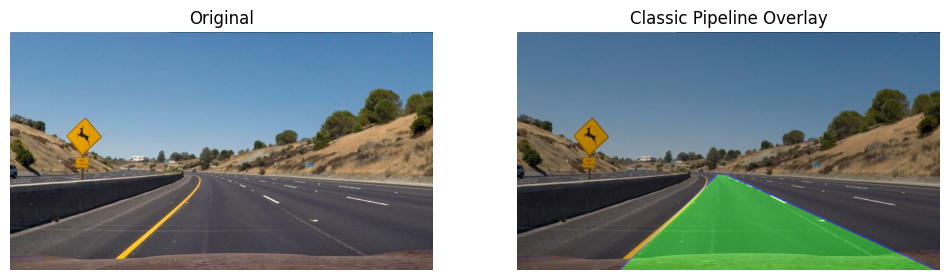

In [ ]:
# Run the classic OpenCV pipeline and show overlay

classic_out = road_lanes.lane_finding_pipeline(frame)
plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1)
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")
plt.subplot(2, 2, 2)
plt.imshow(cv2.cvtColor(classic_out, cv2.COLOR_BGR2RGB))
plt.title("Classic Pipeline Overlay")
plt.axis("off")
plt.subplot(    2, 2, 3)
plt.imshow(
    cv2.addWeighted(
    cv2.cvtColor(fit_lanes, cv2.COLOR_BGR2RGB))
    # else:



## YOLO 

In [2]:
from ultralytics import YOLO

# Load a model
# load a pretrained model (recommended for training)
model = YOLO(
    "../saved_model/yolo-seg-roadlanes.pt",
)

In [ ]:
def apply_blurred_mask(frame, mask):
    # Ensure mask is single channel, apply Gaussian blur
    blurred_mask = cv2.GaussianBlur(mask, (21, 21), 0)

    # Threshold blurred mask to convert back to binary
    _, binary_mask = cv2.threshold(blurred_mask, 127, 255, cv2.THRESH_BINARY)

    # Convert binary mask to 3 channel format to work with the original frame
    binary_mask_3ch = cv2.cvtColor(binary_mask, cv2.COLOR_GRAY2BGR)

    # Apply mask to frame: where mask is white, apply Gaussian blur to frame
    blurred_frame = cv2.GaussianBlur(frame, (21, 21), 0)
    final_frame = np.where(binary_mask_3ch == 255, blurred_frame, frame)

    return final_frame


0: 640x640 3 Lanes, 193.1ms
Speed: 1.9ms preprocess, 193.1ms inference, 2.9ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 3 Lanes, 188.1ms
Speed: 1.3ms preprocess, 188.1ms inference, 2.8ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 2 Lanes, 192.2ms
Speed: 1.3ms preprocess, 192.2ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Lane, 190.9ms
Speed: 1.7ms preprocess, 190.9ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


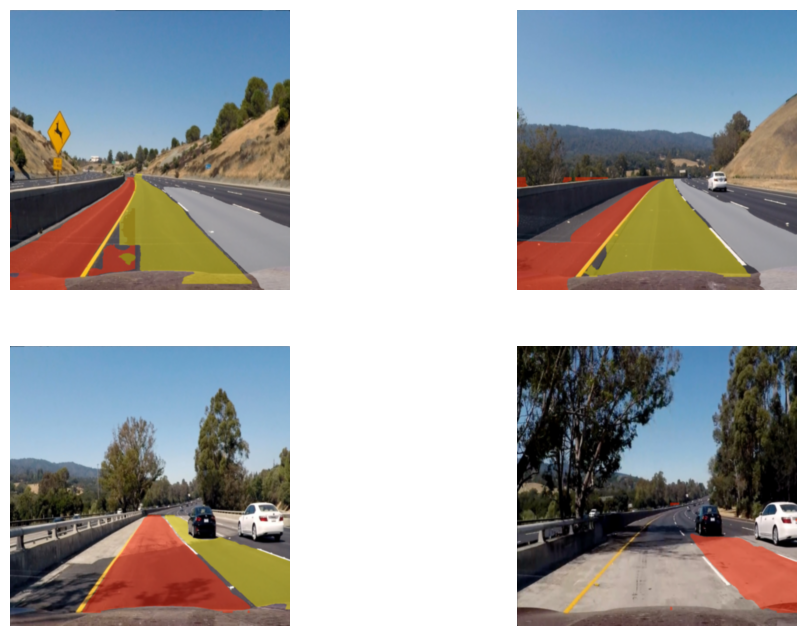

In [ ]:
import cv2
import matplotlib.pylab as plt
import os

image_dir = "../assets/lane/"
all_images = os.listdir(image_dir)
selected_images = ["test2.jpg", "test3.jpg", "test4.jpg", "test5.jpg"]  # all_images[:5]

ax, fig = plt.subplots(2, 2, figsize=(12, 8))
for ix, img_name in enumerate(selected_images):
    ax = plt.subplot(2, 2, ix + 1)
    frame = cv2.imread(os.path.join(image_dir, img_name))
    img_path = os.path.join(image_dir, img_name)
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frame_resized = cv2.resize(rgb, (640, 640))
    results = model.predict(frame_resized)
    # img = cv2.imread(img_path)
    # img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    for result in results:
        plotted_img = result.plot(
            color_mode="instance",
            boxes=False,
        )
        ax.imshow(cv2.GaussianBlur(plotted_img, (5, 5), 0))
        ax.axis("off")
